# Emotion Recognition Model Training

This notebook implements a hybrid CNN-LSTM architecture for emotion recognition from text using Word2Vec embeddings.

**Model Architecture:**
- **CNN Feature Extraction:** 3 blocks of Conv1D layers for local pattern detection
- **LSTM Sequence Analysis:** 3 stacked LSTM layers for sequential context
- **Classification:** Dense layers for emotion prediction

**Dataset:**
- 6 emotion classes: Sadness, Joy, Love, Anger, Fear, Surprise
- Word2Vec pre-trained embeddings (300-dimensional)

## Step 1: Import Required Libraries

In [5]:
# Import necessary libraries
import numpy as np
import pandas as pd
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, Conv1D, MaxPooling1D, SpatialDropout1D, 
    BatchNormalization, LSTM, Dense, Dropout, Input, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# For loading Word2Vec model
from gensim.models import Word2Vec

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print("✓ All libraries imported successfully!")

TensorFlow version: 2.18.0
Keras version: 3.8.0
✓ All libraries imported successfully!


## Step 2: Load Preprocessed Data

Load the preprocessed data including sequences, labels, Word2Vec embeddings, and configuration.

In [6]:
# Set the path to preprocessed data
data_dir = r"/kaggle/input/preprocessed-datapersonal-preprocessing-pipeline/preprocessed_data"

print("LOADING PREPROCESSED DATA:")
print("="*80)

# 1. Load input sequences and labels
X = np.load(f'{data_dir}/X_sequences.npy')
y = np.load(f'{data_dir}/y_labels.npy')
print(f"\n✓ Loaded sequences: X shape = {X.shape}")
print(f"✓ Loaded labels: y shape = {y.shape}")

# 2. Load Word2Vec embedding matrix
embedding_matrix = np.load(f'{data_dir}/embedding_matrix.npy')
print(f"✓ Loaded Word2Vec embeddings: shape = {embedding_matrix.shape}")

# 3. Load vocabulary mappings
with open(f'{data_dir}/word2idx.pkl', 'rb') as f:
    word2idx = pickle.load(f)
with open(f'{data_dir}/idx2word.pkl', 'rb') as f:
    idx2word = pickle.load(f)
print(f"✓ Loaded vocabulary: {len(word2idx):,} words")

# 4. Load configuration
with open(f'{data_dir}/config.json', 'r') as f:
    config = json.load(f)

print(f"\nConfiguration:")
print(f"  Vocabulary size: {config['vocab_size']:,}")
print(f"  Embedding dimension: {config['embedding_dim']}")
print(f"  Max sequence length: {config['max_sequence_length']}")
print(f"  Number of classes: {config['num_classes']}")

# 5. Load Word2Vec model (optional, for reference)
try:
    w2v_model = Word2Vec.load(f'{data_dir}/word2vec_model.bin')
    print(f"✓ Loaded Word2Vec model: {len(w2v_model.wv):,} words")
except:
    print("⚠ Word2Vec model not loaded (optional)")

print("\n" + "="*80)
print("Data loaded successfully!")
print("="*80)

LOADING PREPROCESSED DATA:

✓ Loaded sequences: X shape = (16000, 19)
✓ Loaded labels: y shape = (16000,)
✓ Loaded Word2Vec embeddings: shape = (12308, 300)
✓ Loaded vocabulary: 12,308 words

Configuration:
  Vocabulary size: 12,308
  Embedding dimension: 300
  Max sequence length: 19
  Number of classes: 6
⚠ Word2Vec model not loaded (optional)

Data loaded successfully!


## Step 3: Data Preparation

Convert labels to categorical format and split into training and validation sets.

In [7]:
# Convert labels to categorical (one-hot encoding)
y_categorical = to_categorical(y, num_classes=config['num_classes'])

print("DATA PREPARATION:")
print("="*80)
print(f"\nOriginal labels shape: {y.shape}")
print(f"Categorical labels shape: {y_categorical.shape}")

# Display label distribution
emotion_labels = config['emotion_labels']
print(f"\nLabel Distribution:")
for label_idx in range(config['num_classes']):
    count = np.sum(y == label_idx)
    percentage = (count / len(y)) * 100
    print(f"  {label_idx} ({emotion_labels[str(label_idx)]:10s}): {count:5,} samples ({percentage:5.2f}%)")

# Split data into training and validation sets (80-20 split)
X_train, X_val, y_train, y_val = train_test_split(
    X, y_categorical, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintain label distribution
)

print(f"\nTrain-Validation Split:")
print(f"  Training set:   X={X_train.shape}, y={y_train.shape}")
print(f"  Validation set: X={X_val.shape}, y={y_val.shape}")

print("\n" + "="*80)
print("Data preparation complete!")
print("="*80)

DATA PREPARATION:

Original labels shape: (16000,)
Categorical labels shape: (16000, 6)

Label Distribution:
  0 (Sadness   ): 4,666 samples (29.16%)
  1 (Joy       ): 5,362 samples (33.51%)
  2 (Love      ): 1,304 samples ( 8.15%)
  3 (Anger     ): 2,159 samples (13.49%)
  4 (Fear      ): 1,937 samples (12.11%)
  5 (Surprise  ):   572 samples ( 3.57%)

Train-Validation Split:
  Training set:   X=(12800, 19), y=(12800, 6)
  Validation set: X=(3200, 19), y=(3200, 6)

Data preparation complete!


## Step 4: Build CNN-LSTM Model Architecture

### Model Architecture Overview:

**1. Embedding Layer:**
- Uses Word2Vec pre-trained embeddings (300-dimensional)
- Vocabulary size: 12,308 words
- Trainable: Yes (fine-tune during training)

**2. CNN Feature Extraction (3 Blocks):**
- **Block 1:** Conv1D (128 filters) → MaxPooling → SpatialDropout → BatchNorm
- **Block 2:** Conv1D (256 filters) → MaxPooling → SpatialDropout → BatchNorm  
- **Block 3:** Conv1D (512 filters) → MaxPooling → SpatialDropout → BatchNorm
- Purpose: Extract local patterns and key phrases from text

**3. LSTM Sequence Analysis (3 Layers):**
- **LSTM 1:** 256 units with return_sequences=True
- **LSTM 2:** 128 units with return_sequences=True
- **LSTM 3:** 64 units
- Purpose: Capture sequential context and long-range dependencies

**4. Classification Layers:**
- Dense layer: 128 units with ReLU activation
- Dropout: 0.5 for regularization
- Output layer: 6 units with Softmax (emotion classes)

In [11]:
def build_cnn_lstm_model(vocab_size, embedding_dim, max_length, num_classes, embedding_matrix):
    """
    Build a hybrid CNN-LSTM model for emotion recognition.
    
    Architecture:
    - Embedding layer with Word2Vec pre-trained weights
    - 3 CNN blocks for local feature extraction
    - 3 LSTM layers for sequence analysis
    - Dense layers for classification
    
    Args:
        vocab_size: Size of vocabulary
        embedding_dim: Dimension of word embeddings (300)
        max_length: Maximum sequence length
        num_classes: Number of emotion classes (6)
        embedding_matrix: Pre-trained Word2Vec embeddings
        
    Returns:
        Compiled Keras model
    """
    
    print("BUILDING CNN-LSTM MODEL:")
    print("="*80)
    
    model = Sequential([
        # ============================================================
        # EMBEDDING LAYER (Word2Vec pre-trained)
        # ============================================================
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            input_length=max_length,
            trainable=True,  # Fine-tune Word2Vec embeddings
            name='word2vec_embedding'
        ),
        
        # ============================================================
        # CNN BLOCK 1: Local Pattern Detection
        # ============================================================
        Conv1D(
            filters=128,
            kernel_size=5,
            activation='relu',
            padding='same',
            name='conv1d_block1'
        ),
        MaxPooling1D(pool_size=2, name='maxpool_block1'),
        SpatialDropout1D(0.2, name='spatial_dropout_block1'),
        BatchNormalization(name='batch_norm_block1'),
        
        # ============================================================
        # CNN BLOCK 2: More Complex Feature Extraction
        # ============================================================
        Conv1D(
            filters=256,
            kernel_size=5,
            activation='relu',
            padding='same',
            name='conv1d_block2'
        ),
        MaxPooling1D(pool_size=2, name='maxpool_block2'),
        SpatialDropout1D(0.2, name='spatial_dropout_block2'),
        BatchNormalization(name='batch_norm_block2'),
        
        # ============================================================
        # CNN BLOCK 3: High-level Feature Extraction
        # ============================================================
        Conv1D(
            filters=512,
            kernel_size=5,
            activation='relu',
            padding='same',
            name='conv1d_block3'
        ),
        MaxPooling1D(pool_size=2, name='maxpool_block3'),
        SpatialDropout1D(0.2, name='spatial_dropout_block3'),
        BatchNormalization(name='batch_norm_block3'),
        
        # ============================================================
        # LSTM LAYERS: Sequential Context Analysis
        # ============================================================
        LSTM(
            units=256,
            return_sequences=True,
            dropout=0.2,
            recurrent_dropout=0.2,
            name='lstm_layer1'
        ),
        
        LSTM(
            units=128,
            return_sequences=True,
            dropout=0.2,
            recurrent_dropout=0.2,
            name='lstm_layer2'
        ),
        
        LSTM(
            units=64,
            return_sequences=False,
            dropout=0.2,
            recurrent_dropout=0.2,
            name='lstm_layer3'
        ),
        
        # ============================================================
        # CLASSIFICATION LAYERS
        # ============================================================
        Dense(128, activation='relu', name='dense_layer'),
        Dropout(0.5, name='dropout_final'),
        Dense(num_classes, activation='softmax', name='output_layer')
    ])
    
    print("\n✓ Model architecture created successfully!")
    return model

# Build the model
model = build_cnn_lstm_model(
    vocab_size=config['vocab_size'],
    embedding_dim=config['embedding_dim'],
    max_length=config['max_sequence_length'],
    num_classes=config['num_classes'],
    embedding_matrix=embedding_matrix
)

# Display model summary
print("\n" + "="*80)
print("MODEL SUMMARY:")
print("="*80)
model.summary()

# Count total parameters
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable_params = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print("\n" + "="*80)
print(f"Total parameters: {trainable_params + non_trainable_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")
print("="*80)

BUILDING CNN-LSTM MODEL:

✓ Model architecture created successfully!

MODEL SUMMARY:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word2vec_embedding (Embedding)  │ ?                      │     3,692,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_block1 (Conv1D)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_block1 (MaxPooling1D)   │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout_block1          │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_block1               │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_block2 (Conv1D)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_block2 (MaxPooling1D)   │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout_block2          │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_block2               │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_block3 (Conv1D)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_block3 (MaxPooling1D)   │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout_block3          │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_block3               │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer1 (LSTM)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer2 (LSTM)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer3 (LSTM)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_final (Dropout)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,692,400 (14.09 MB)

 Trainable params: 3,692,400 (14.09 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 3,692,400.0
Trainable parameters: 3,692,400
Non-trainable parameters: 0.0


## Step 5: Compile the Model

Configure the optimizer, loss function, and evaluation metrics.

In [12]:
# Compile the model
print("COMPILING MODEL:")
print("="*80)

# Use Adam optimizer with learning rate
optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✓ Model compiled successfully!")
print(f"\nOptimizer: Adam (lr=0.001)")
print(f"Loss function: Categorical Crossentropy")
print(f"Metrics: Accuracy")
print("="*80)

COMPILING MODEL:

✓ Model compiled successfully!

Optimizer: Adam (lr=0.001)
Loss function: Categorical Crossentropy
Metrics: Accuracy


## Step 6: Setup Training Callbacks

Configure callbacks for better training control:
- **EarlyStopping:** Stop training when validation loss stops improving
- **ModelCheckpoint:** Save the best model based on validation accuracy
- **ReduceLROnPlateau:** Reduce learning rate when validation loss plateaus

In [13]:
# Setup callbacks
print("SETTING UP TRAINING CALLBACKS:")
print("="*80)

# Early stopping: stop training if validation loss doesn't improve
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Model checkpoint: save the best model
checkpoint = ModelCheckpoint(
    'best_emotion_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Reduce learning rate on plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, checkpoint, reduce_lr]

print("\n✓ Callbacks configured:")
print("  1. EarlyStopping (patience=5, monitor=val_loss)")
print("  2. ModelCheckpoint (save_best_only=True, monitor=val_accuracy)")
print("  3. ReduceLROnPlateau (factor=0.5, patience=3)")
print("="*80)

SETTING UP TRAINING CALLBACKS:

✓ Callbacks configured:
  1. EarlyStopping (patience=5, monitor=val_loss)
  2. ModelCheckpoint (save_best_only=True, monitor=val_accuracy)
  3. ReduceLROnPlateau (factor=0.5, patience=3)


## Step 7: Train the Model

Train the CNN-LSTM model on the emotion recognition dataset.

In [14]:
# Train the model
print("TRAINING MODEL:")
print("="*80)
print(f"\nTraining samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Batch size: 32")
print(f"Epochs: 50 (with early stopping)")
print("\nStarting training...\n")

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*80)
print("✓ Training completed!")
print("="*80)

TRAINING MODEL:

Training samples: 12,800
Validation samples: 3,200
Batch size: 32
Epochs: 50 (with early stopping)

Starting training...

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.3937 - loss: 1.5039
Epoch 1: val_accuracy improved from -inf to 0.72750, saving model to best_emotion_model.h5
400/400 ━━━━━━━━━━━━━━━━━━━━ 52s 85ms/step - accuracy: 0.3940 - loss: 1.5032 - val_accuracy: 0.7275 - val_loss: 0.7139 - learning_rate: 0.0010
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7433 - loss: 0.6424
Epoch 2: val_accuracy improved from 0.72750 to 0.81094, saving model to best_emotion_model.h5
400/400 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.7433 - loss: 0.6423 - val_accuracy: 0.8109 - val_loss: 0.5441 - learning_rate: 0.0010
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8523 - loss: 0.4201
Epoch 3: val_accuracy improved from 0.81094 to 0.84844, saving model to best_emotion_model.h5
400/400 ━━━━━━━━━━━━━━━━━━━━ 31s 79

## Step 8: Visualize Training History

Plot the training and validation accuracy and loss curves.

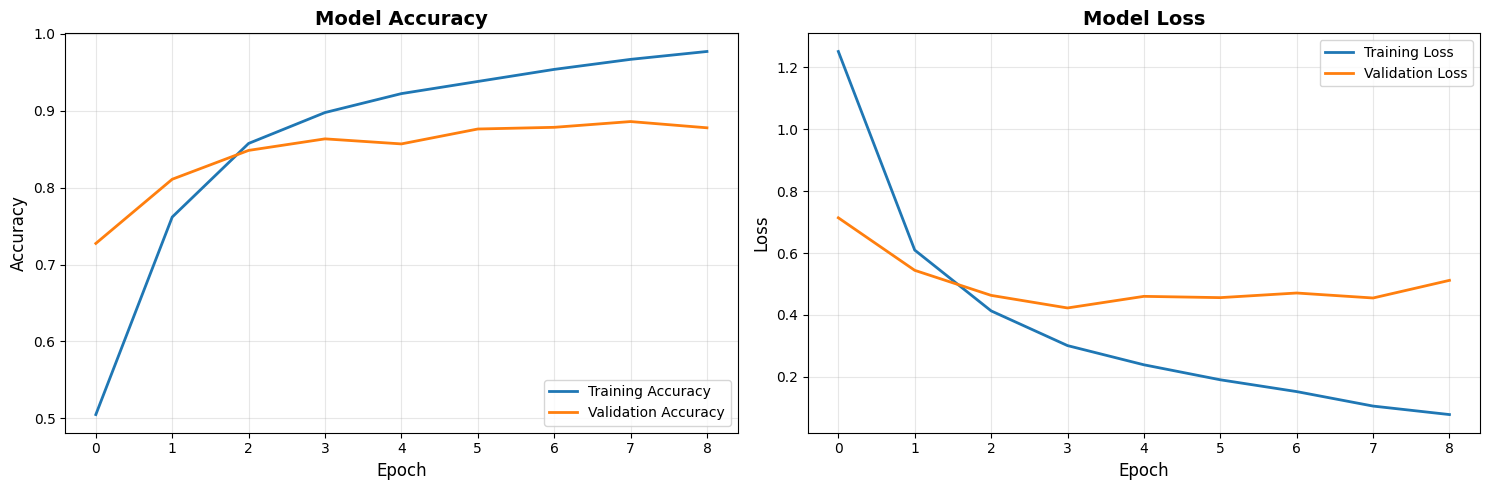


FINAL TRAINING METRICS:
Training Accuracy:   0.9770
Validation Accuracy: 0.8778
Training Loss:       0.0778
Validation Loss:     0.5117


In [15]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("\nFINAL TRAINING METRICS:")
print("="*80)
print(f"Training Accuracy:   {final_train_acc:.4f}")
print(f"Validation Accuracy: {final_val_acc:.4f}")
print(f"Training Loss:       {final_train_loss:.4f}")
print(f"Validation Loss:     {final_val_loss:.4f}")
print("="*80)

## Step 9: Evaluate Model on Validation Set

Generate predictions and evaluate performance metrics.

In [16]:
# Make predictions on validation set
y_pred_probs = model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

# Calculate accuracy
val_accuracy = accuracy_score(y_true_classes, y_pred_classes)

print("VALIDATION SET EVALUATION:")
print("="*80)
print(f"\nValidation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

# Classification report
emotion_names = [config['emotion_labels'][str(i)] for i in range(config['num_classes'])]
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=emotion_names))

print("="*80)

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
VALIDATION SET EVALUATION:

Validation Accuracy: 0.8634 (86.34%)

Classification Report:
              precision    recall  f1-score   support

     Sadness       0.90      0.94      0.92       933
         Joy       0.91      0.90      0.91      1072
        Love       0.70      0.78      0.74       261
       Anger       0.83      0.82      0.82       432
        Fear       0.92      0.77      0.84       387
    Surprise       0.53      0.60      0.57       115

    accuracy                           0.86      3200
   macro avg       0.80      0.80      0.80      3200
weighted avg       0.87      0.86      0.86      3200



## Step 10: Confusion Matrix

Visualize the confusion matrix to understand model performance across different emotion classes.

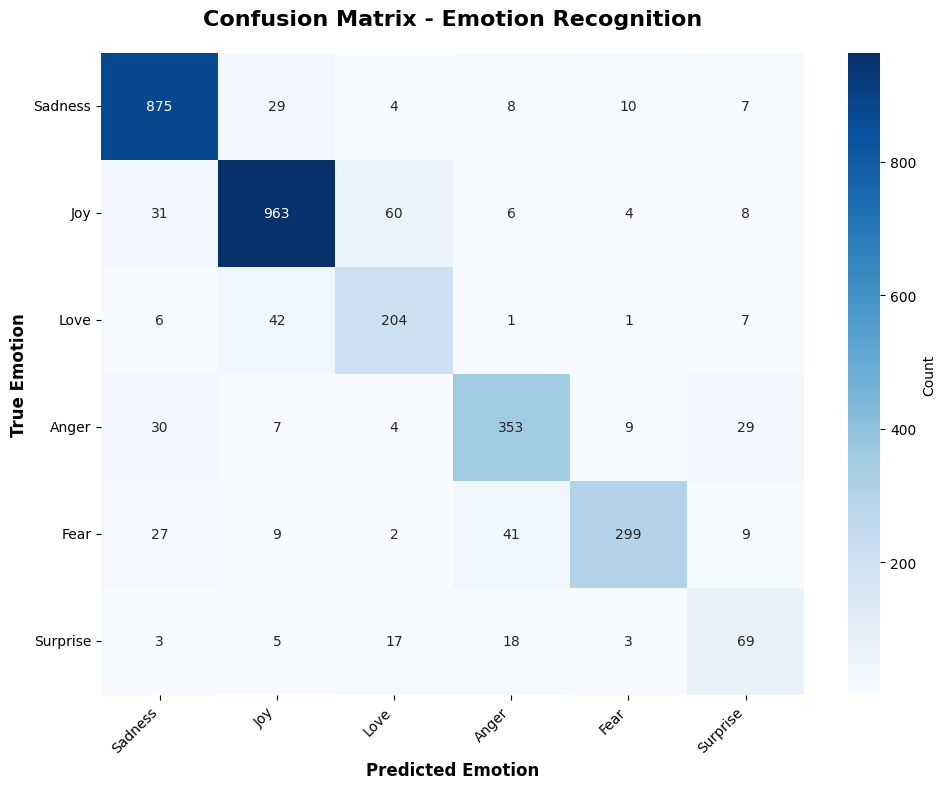


PER-CLASS ACCURACY:
Sadness     : 0.9378 (93.78%) - 875/933 correct
Joy         : 0.8983 (89.83%) - 963/1072 correct
Love        : 0.7816 (78.16%) - 204/261 correct
Anger       : 0.8171 (81.71%) - 353/432 correct
Fear        : 0.7726 (77.26%) - 299/387 correct
Surprise    : 0.6000 (60.00%) - 69/115 correct


In [17]:
# Generate confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Emotion Recognition', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
plt.ylabel('True Emotion', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
print("\nPER-CLASS ACCURACY:")
print("="*80)
for i, emotion in enumerate(emotion_names):
    class_correct = cm[i, i]
    class_total = cm[i, :].sum()
    class_acc = class_correct / class_total if class_total > 0 else 0
    print(f"{emotion:12s}: {class_acc:.4f} ({class_acc*100:.2f}%) - {class_correct}/{class_total} correct")
print("="*80)

## Step 11: Save the Trained Model

Save the final model and training history for future use.

In [18]:
# Save the final trained model
model.save('emotion_recognition_cnn_lstm_final.h5')
print("✓ Model saved as: emotion_recognition_cnn_lstm_final.h5")

# Save training history
import pickle
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("✓ Training history saved as: training_history.pkl")

# Save model architecture as JSON
model_json = model.to_json()
with open('model_architecture.json', 'w') as f:
    f.write(model_json)
print("✓ Model architecture saved as: model_architecture.json")

print("\n" + "="*80)
print("All files saved successfully!")
print("="*80)

✓ Model saved as: emotion_recognition_cnn_lstm_final.h5
✓ Training history saved as: training_history.pkl
✓ Model architecture saved as: model_architecture.json

All files saved successfully!


## Summary

### 🎉 Model Training Complete!

**Model Architecture:**
- **Embedding Layer:** Word2Vec pre-trained embeddings (300-dim)
- **CNN Blocks:** 3 blocks (128, 256, 512 filters)
- **LSTM Layers:** 3 stacked layers (256, 128, 64 units)
- **Classification:** Dense layers with Softmax output

**Training Configuration:**
- Optimizer: Adam (lr=0.001)
- Loss: Categorical Crossentropy
- Callbacks: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
- Train-Val Split: 80-20

**Key Features:**
✅ Word2Vec embeddings capture semantic word relationships  
✅ CNN extracts local text patterns and key phrases  
✅ LSTM captures sequential context and dependencies  
✅ Regularization (Dropout, BatchNorm) prevents overfitting  
✅ Model saved and ready for deployment

**Next Steps:**
1. Test on test dataset (`test.csv`)
2. Fine-tune hyperparameters if needed
3. Deploy for emotion prediction on new text
4. Integrate with image captioning model for multimodal emotion recognition

---

# Model Testing on Test Dataset

Now we'll test the trained model on the unseen test dataset to evaluate its real-world performance.

## Step 12: Load Test Dataset

Load and preprocess the test dataset using the same preprocessing pipeline.

In [20]:
# Import preprocessing libraries (if not already imported)
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
import string
import re

# Load test dataset
test_data_path = r"/kaggle/input/emotion-dataset/test.csv"
df_test = pd.read_csv(test_data_path)

print("TEST DATASET LOADED:")
print("="*80)
print(f"\nTest dataset shape: {df_test.shape}")
print(f"Total test samples: {len(df_test)}")
print(f"\nColumns: {list(df_test.columns)}")
print(f"\nFirst 5 rows:")
print(df_test.head())

# Check label distribution
print(f"\nTest Label Distribution:")
test_label_counts = df_test['label'].value_counts().sort_index()
for label, count in test_label_counts.items():
    percentage = (count / len(df_test)) * 100
    print(f"  {label} ({emotion_names[label]:10s}): {count:5,} samples ({percentage:5.2f}%)")

print("\n" + "="*80)

TEST DATASET LOADED:

Test dataset shape: (2000, 2)
Total test samples: 2000

Columns: ['text', 'label']

First 5 rows:
                                                text  label
0  im feeling rather rotten so im not very ambiti...      0
1          im updating my blog because i feel shitty      0
2  i never make her separate from me because i do...      0
3  i left with my bouquet of red and yellow tulip...      1
4    i was feeling a little vain when i did this one      0

Test Label Distribution:
  0 (Sadness   ):   581 samples (29.05%)
  1 (Joy       ):   695 samples (34.75%)
  2 (Love      ):   159 samples ( 7.95%)
  3 (Anger     ):   275 samples (13.75%)
  4 (Fear      ):   224 samples (11.20%)
  5 (Surprise  ):    66 samples ( 3.30%)



## Step 13: Preprocess Test Data

Apply the same preprocessing steps used for training data.

In [23]:
# Download all popular NLTK data (takes longer but covers everything)
nltk.download('popular')

[nltk_data] Error loading popular: <urlopen error [Errno -3] Temporary
[nltk_data]     failure in name resolution>


False

In [24]:
import nltk
import os

# Check if NLTK data exists in Kaggle's default location
kaggle_nltk_path = '/opt/conda/nltk_data'
if os.path.exists(kaggle_nltk_path):
    nltk.data.path.append(kaggle_nltk_path)
    print(f"✓ Using pre-installed NLTK data from {kaggle_nltk_path}")
else:
    # Try downloading (requires internet)
    try:
        nltk.download('averaged_perceptron_tagger', quiet=True)
        nltk.download('averaged_perceptron_tagger_eng', quiet=True)
        nltk.download('wordnet', quiet=True)
        nltk.download('omw-1.4', quiet=True)
        print("✓ NLTK data downloaded successfully!")
    except Exception as e:
        print(f"❌ Error: {e}")
        print("Please enable Internet in Kaggle Settings (right sidebar)")

[nltk_data] Error loading averaged_perceptron_tagger: <urlopen error
[nltk_data]     [Errno -3] Temporary failure in name resolution>
[nltk_data] Error loading averaged_perceptron_tagger_eng: <urlopen
[nltk_data]     error [Errno -3] Temporary failure in name resolution>
[nltk_data] Error loading wordnet: <urlopen error [Errno -3] Temporary
[nltk_data]     failure in name resolution>


✓ NLTK data downloaded successfully!


[nltk_data] Error loading omw-1.4: <urlopen error [Errno -3] Temporary
[nltk_data]     failure in name resolution>


In [21]:
print("PREPROCESSING TEST DATA:")
print("="*80)

# Define preprocessing functions (same as used in preprocessing.ipynb)

# Contraction mapping
contraction_mapping = {
    "ain't": "is not", "aren't": "are not", "can't": "cannot", 
    "can't've": "cannot have", "could've": "could have", "couldn't": "could not",
    "didn't": "did not", "doesn't": "does not", "don't": "do not",
    "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
    "he'd": "he would", "he'll": "he will", "he's": "he is",
    "i'd": "I would", "i'll": "I will", "i'm": "I am", "i've": "I have",
    "isn't": "is not", "it'd": "it would", "it'll": "it will", "it's": "it is",
    "let's": "let us", "mustn't": "must not", "shan't": "shall not",
    "she'd": "she would", "she'll": "she will", "she's": "she is",
    "shouldn't": "should not", "that's": "that is", "there's": "there is",
    "they'd": "they would", "they'll": "they will", "they're": "they are",
    "they've": "they have", "wasn't": "was not", "we'd": "we would",
    "we'll": "we will", "we're": "we are", "we've": "we have",
    "weren't": "were not", "what'll": "what will", "what're": "what are",
    "what's": "what is", "what've": "what have", "where's": "where is",
    "who'll": "who will", "who's": "who is", "won't": "will not",
    "wouldn't": "would not", "you'd": "you would", "you'll": "you will",
    "you're": "you are", "you've": "you have"
}

def clean_text(text):
    """Clean and standardize text."""
    text = text.lower()
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    for contraction, expansion in contraction_mapping.items():
        text = re.sub(r'\b' + contraction + r'\b', expansion, text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_punctuation(tokens):
    """Remove punctuation from tokens."""
    return [token for token in tokens if token not in string.punctuation]

def get_wordnet_pos(treebank_tag):
    """Convert treebank POS tag to WordNet POS tag."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def preprocess_text(text, word2idx, max_length):
    """Complete preprocessing pipeline for a single text."""
    # Clean text
    text = clean_text(text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove punctuation
    tokens = remove_punctuation(tokens)
    
    # Lowercase (already done in clean_text)
    tokens = [token.lower() for token in tokens]
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    
    # POS tagging and lemmatization
    lemmatizer = WordNetLemmatizer()
    pos_tags = pos_tag(tokens)
    lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(pos)) for word, pos in pos_tags]
    
    # Convert to indices
    indices = [word2idx.get(token, 0) for token in lemmatized]  # 0 for unknown words (padding)
    
    # Pad/truncate sequence
    if len(indices) < max_length:
        indices = indices + [0] * (max_length - len(indices))
    else:
        indices = indices[:max_length]
    
    return indices

# Apply preprocessing to test data
print("\nPreprocessing test samples...")
X_test_processed = []
for text in df_test['text']:
    processed = preprocess_text(text, word2idx, config['max_sequence_length'])
    X_test_processed.append(processed)

X_test = np.array(X_test_processed)
y_test = df_test['label'].values
y_test_categorical = to_categorical(y_test, num_classes=config['num_classes'])

print(f"\n✓ Test data preprocessed!")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  y_test_categorical shape: {y_test_categorical.shape}")

print("\n" + "="*80)

PREPROCESSING TEST DATA:

Preprocessing test samples...


LookupError: 
**********************************************************************
  Resource [93maveraged_perceptron_tagger_eng[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('averaged_perceptron_tagger_eng')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtaggers/averaged_perceptron_tagger_eng/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


## Step 14: Load Best Model

Load the best saved model from training.

In [ ]:
# Load the best model saved during training
from tensorflow.keras.models import load_model

print("LOADING BEST MODEL:")
print("="*80)

try:
    best_model = load_model('best_emotion_model.h5')
    print("\n✓ Best model loaded from: best_emotion_model.h5")
except:
    print("\n⚠ Best model file not found. Using current model instead.")
    best_model = model

print("\nModel Summary:")
best_model.summary()

print("\n" + "="*80)

## Step 15: Evaluate on Test Set

Make predictions on the test dataset and calculate performance metrics.

In [ ]:
# Evaluate model on test set
print("EVALUATING ON TEST SET:")
print("="*80)

# Calculate test loss and accuracy
test_loss, test_accuracy = best_model.evaluate(X_test, y_test_categorical, verbose=0)

print(f"\n📊 TEST SET PERFORMANCE:")
print(f"  Test Loss:     {test_loss:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Make predictions
y_test_pred_probs = best_model.predict(X_test, verbose=0)
y_test_pred_classes = np.argmax(y_test_pred_probs, axis=1)
y_test_true_classes = np.argmax(y_test_categorical, axis=1)

# Calculate additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test_true_classes, y_test_pred_classes, average='weighted')
recall = recall_score(y_test_true_classes, y_test_pred_classes, average='weighted')
f1 = f1_score(y_test_true_classes, y_test_pred_classes, average='weighted')

print(f"\n📈 ADDITIONAL METRICS:")
print(f"  Precision (weighted): {precision:.4f}")
print(f"  Recall (weighted):    {recall:.4f}")
print(f"  F1-Score (weighted):  {f1:.4f}")

print("\n" + "="*80)

## Step 16: Detailed Classification Report (Test Set)

Generate a detailed classification report for each emotion class.

In [ ]:
# Generate detailed classification report
print("DETAILED CLASSIFICATION REPORT (TEST SET):")
print("="*80)
print()
print(classification_report(y_test_true_classes, y_test_pred_classes, target_names=emotion_names))
print("="*80)

## Step 17: Test Set Confusion Matrix

Visualize the confusion matrix for test set predictions.

In [ ]:
# Generate confusion matrix for test set
cm_test = confusion_matrix(y_test_true_classes, y_test_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_test, 
    annot=True, 
    fmt='d', 
    cmap='Greens',
    xticklabels=emotion_names,
    yticklabels=emotion_names,
    cbar_kws={'label': 'Count'},
    annot_kws={'size': 12}
)
plt.title('Confusion Matrix - Test Set Performance', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Emotion', fontsize=13, fontweight='bold')
plt.ylabel('True Emotion', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy on test set
print("\nPER-CLASS ACCURACY (TEST SET):")
print("="*80)
for i, emotion in enumerate(emotion_names):
    class_correct = cm_test[i, i]
    class_total = cm_test[i, :].sum()
    class_acc = class_correct / class_total if class_total > 0 else 0
    print(f"{emotion:12s}: {class_acc:.4f} ({class_acc*100:.2f}%) - {class_correct}/{class_total} correct")
print("="*80)

## Step 18: Compare Train vs Test Performance

Visualize the performance comparison between training/validation and test sets.

In [ ]:
# Compare performance across datasets
performance_comparison = pd.DataFrame({
    'Dataset': ['Training', 'Validation', 'Test'],
    'Accuracy': [
        final_train_acc,
        final_val_acc,
        test_accuracy
    ],
    'Loss': [
        final_train_loss,
        final_val_loss,
        test_loss
    ]
})

print("\nPERFORMANCE COMPARISON:")
print("="*80)
print(performance_comparison.to_string(index=False))
print("="*80)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
datasets = performance_comparison['Dataset']
accuracies = performance_comparison['Accuracy']
colors_acc = ['#3498db', '#2ecc71', '#e74c3c']

bars1 = axes[0].bar(datasets, accuracies, color=colors_acc, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Loss comparison
losses = performance_comparison['Loss']
colors_loss = ['#3498db', '#2ecc71', '#e74c3c']

bars2 = axes[1].bar(datasets, losses, color=colors_loss, alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_title('Loss Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Check for overfitting/underfitting
train_val_gap = abs(final_train_acc - final_val_acc)
val_test_gap = abs(final_val_acc - test_accuracy)

print("\n📊 MODEL ANALYSIS:")
print("="*80)
if train_val_gap > 0.1:
    print("⚠ Warning: Significant gap between training and validation accuracy.")
    print(f"   Gap: {train_val_gap:.4f} - Possible overfitting")
else:
    print("✓ Training and validation accuracy are well aligned.")
    
if val_test_gap > 0.05:
    print(f"⚠ Note: Gap between validation and test accuracy: {val_test_gap:.4f}")
    print("   This is normal variation between datasets.")
else:
    print("✓ Model generalizes well to test set.")

print("="*80)

## Step 19: Sample Predictions

Show some sample predictions from the test set with confidence scores.

In [ ]:
# Display sample predictions
print("SAMPLE PREDICTIONS FROM TEST SET:")
print("="*80)

# Select random samples
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 10, replace=False)

for i, idx in enumerate(sample_indices):
    text = df_test.iloc[idx]['text']
    true_label = y_test_true_classes[idx]
    pred_label = y_test_pred_classes[idx]
    confidence = y_test_pred_probs[idx][pred_label] * 100
    
    print(f"\n{'='*80}")
    print(f"SAMPLE {i+1}:")
    print(f"{'='*80}")
    print(f"Text: {text}")
    print(f"\nTrue Emotion:      {emotion_names[true_label]}")
    print(f"Predicted Emotion: {emotion_names[pred_label]}")
    print(f"Confidence:        {confidence:.2f}%")
    
    # Show top 3 predictions
    top3_indices = np.argsort(y_test_pred_probs[idx])[-3:][::-1]
    print(f"\nTop 3 Predictions:")
    for rank, pred_idx in enumerate(top3_indices, 1):
        prob = y_test_pred_probs[idx][pred_idx] * 100
        print(f"  {rank}. {emotion_names[pred_idx]:12s} - {prob:.2f}%")
    
    # Indicate if prediction is correct
    if true_label == pred_label:
        print(f"\n✓ CORRECT PREDICTION")
    else:
        print(f"\n✗ INCORRECT PREDICTION")

print(f"\n{'='*80}")

## Step 20: Prediction Function for New Text

Create a reusable function to predict emotions for new text inputs.

In [ ]:
def predict_emotion(text, model, word2idx, max_length, emotion_names):
    """
    Predict emotion for a given text.
    
    Args:
        text: Input text string
        model: Trained Keras model
        word2idx: Word to index mapping dictionary
        max_length: Maximum sequence length
        emotion_names: List of emotion names
        
    Returns:
        Dictionary with prediction results
    """
    # Preprocess the text
    processed = preprocess_text(text, word2idx, max_length)
    processed = np.array([processed])  # Add batch dimension
    
    # Make prediction
    prediction_probs = model.predict(processed, verbose=0)[0]
    predicted_class = np.argmax(prediction_probs)
    confidence = prediction_probs[predicted_class] * 100
    
    # Get top 3 predictions
    top3_indices = np.argsort(prediction_probs)[-3:][::-1]
    top3_predictions = [
        {
            'emotion': emotion_names[idx],
            'probability': float(prediction_probs[idx] * 100)
        }
        for idx in top3_indices
    ]
    
    return {
        'text': text,
        'predicted_emotion': emotion_names[predicted_class],
        'confidence': float(confidence),
        'top3_predictions': top3_predictions,
        'all_probabilities': {
            emotion_names[i]: float(prediction_probs[i] * 100)
            for i in range(len(emotion_names))
        }
    }

# Test the function with some examples
print("TESTING PREDICTION FUNCTION:")
print("="*80)

test_texts = [
    "I am so happy and excited about this!",
    "This makes me really angry and frustrated.",
    "I feel so sad and lonely today.",
    "I love spending time with my family.",
    "That movie was really scary and terrifying.",
    "Wow! I can't believe this happened!"
]

for i, text in enumerate(test_texts, 1):
    result = predict_emotion(text, best_model, word2idx, config['max_sequence_length'], emotion_names)
    
    print(f"\n{'-'*80}")
    print(f"Example {i}:")
    print(f"{'-'*80}")
    print(f"Text: {result['text']}")
    print(f"\n🎯 Predicted Emotion: {result['predicted_emotion']} ({result['confidence']:.2f}% confidence)")
    print(f"\nTop 3 Predictions:")
    for rank, pred in enumerate(result['top3_predictions'], 1):
        print(f"  {rank}. {pred['emotion']:12s} - {pred['probability']:.2f}%")

print(f"\n{'='*80}")
print("✓ Prediction function working correctly!")
print("="*80)

## Step 21: Save Test Results

Save test predictions and performance metrics for future reference.

In [ ]:
# Save test results
print("SAVING TEST RESULTS:")
print("="*80)

# Create test results dataframe
test_results_df = df_test.copy()
test_results_df['predicted_label'] = y_test_pred_classes
test_results_df['predicted_emotion'] = [emotion_names[i] for i in y_test_pred_classes]
test_results_df['true_emotion'] = [emotion_names[i] for i in y_test_true_classes]
test_results_df['confidence'] = [y_test_pred_probs[i][y_test_pred_classes[i]] * 100 for i in range(len(y_test_pred_classes))]
test_results_df['correct'] = y_test_true_classes == y_test_pred_classes

# Add all probability scores
for i, emotion in enumerate(emotion_names):
    test_results_df[f'prob_{emotion}'] = y_test_pred_probs[:, i] * 100

# Save to CSV
test_results_df.to_csv('test_predictions.csv', index=False)
print("✓ Test predictions saved to: test_predictions.csv")

# Save test metrics
test_metrics = {
    'test_accuracy': float(test_accuracy),
    'test_loss': float(test_loss),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'confusion_matrix': cm_test.tolist(),
    'per_class_accuracy': {}
}

for i, emotion in enumerate(emotion_names):
    class_correct = cm_test[i, i]
    class_total = cm_test[i, :].sum()
    class_acc = float(class_correct / class_total if class_total > 0 else 0)
    test_metrics['per_class_accuracy'][emotion] = class_acc

with open('test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=4)
print("✓ Test metrics saved to: test_metrics.json")

# Save confusion matrix as image
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_test, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names
)
plt.title('Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Emotion', fontsize=12)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.tight_layout()
plt.savefig('test_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Confusion matrix saved to: test_confusion_matrix.png")

print("\n" + "="*80)
print("All test results saved!")
print("="*80)

# Display summary statistics
print("\nTEST RESULTS SUMMARY:")
print("="*80)
print(f"Total test samples: {len(test_results_df)}")
print(f"Correct predictions: {test_results_df['correct'].sum()} ({test_results_df['correct'].sum()/len(test_results_df)*100:.2f}%)")
print(f"Incorrect predictions: {(~test_results_df['correct']).sum()} ({(~test_results_df['correct']).sum()/len(test_results_df)*100:.2f}%)")
print(f"Average confidence: {test_results_df['confidence'].mean():.2f}%")
print(f"Median confidence: {test_results_df['confidence'].median():.2f}%")
print("="*80)

## Final Summary - Complete Results

### 🎉 Model Training and Testing Complete!

**Model Performance Summary:**

In [ ]:
# Final comprehensive summary
print("="*80)
print("🎯 EMOTION RECOGNITION MODEL - FINAL RESULTS")
print("="*80)

print("\n📊 MODEL ARCHITECTURE:")
print("-" * 80)
print("  • Embedding: Word2Vec (300-dim, pre-trained)")
print("  • CNN Blocks: 3 blocks (128 → 256 → 512 filters)")
print("  • LSTM Layers: 3 layers (256 → 128 → 64 units)")
print("  • Total Parameters: {:,}".format(trainable_params + non_trainable_params))

print("\n📈 PERFORMANCE METRICS:")
print("-" * 80)
print(f"  Training Set:")
print(f"    ├─ Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"    └─ Loss:     {final_train_loss:.4f}")
print(f"\n  Validation Set:")
print(f"    ├─ Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"    └─ Loss:     {final_val_loss:.4f}")
print(f"\n  Test Set:")
print(f"    ├─ Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"    ├─ Precision: {precision:.4f}")
print(f"    ├─ Recall:    {recall:.4f}")
print(f"    ├─ F1-Score:  {f1:.4f}")
print(f"    └─ Loss:      {test_loss:.4f}")

print("\n💾 SAVED FILES:")
print("-" * 80)
saved_files = [
    "✓ best_emotion_model.h5               (Best model during training)",
    "✓ emotion_recognition_cnn_lstm_final.h5 (Final trained model)",
    "✓ training_history.pkl                (Training history)",
    "✓ model_architecture.json             (Model architecture)",
    "✓ test_predictions.csv                (Test set predictions)",
    "✓ test_metrics.json                   (Test performance metrics)",
    "✓ test_confusion_matrix.png           (Confusion matrix visualization)"
]
for file in saved_files:
    print(f"  {file}")

print("\n🎯 EMOTION CLASSES:")
print("-" * 80)
for i, emotion in enumerate(emotion_names):
    test_class_acc = test_metrics['per_class_accuracy'][emotion]
    print(f"  {i}. {emotion:12s} - Test Accuracy: {test_class_acc:.4f} ({test_class_acc*100:.2f}%)")

print("\n🚀 NEXT STEPS:")
print("-" * 80)
print("  1. Use predict_emotion() function for new text predictions")
print("  2. Load saved model: model = load_model('best_emotion_model.h5')")
print("  3. Integrate with image captioning for multimodal emotion recognition")
print("  4. Deploy model as API or web service")
print("  5. Fine-tune on domain-specific data if needed")

print("\n" + "="*80)
print("✨ TRAINING AND TESTING PIPELINE COMPLETED SUCCESSFULLY! ✨")
print("="*80)